In [90]:
import matplotlib
import pickle
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sb
from scipy import stats
from scipy.stats import binom
import datetime
import statistics
import multiprocess as mp
import time
import arviz as az
from sklearn.metrics import mean_squared_error

from epydemix import EpiModel
from epydemix import load_predefined_model
from epydemix.visualization import plot_quantiles, plot_trajectories, plot_posterior_distribution_2d
from epydemix.population import load_epydemix_population, Population, get_available_locations
from epydemix.visualization import plot_contact_matrix, plot_population
from epydemix.utils import compute_simulation_dates
from epydemix import simulate
from epydemix.calibration import ABCSampler, rmse
import matplotlib.pyplot as plt
import pandas as pd
from epydemix.visualization import plot_posterior_distribution

from Epy_functions import stochastic_sir
from Epy_functions import stochastic_sir_noisy
from Epy_functions import summary
from Epy_functions import weighted_ess

observed_data_phi_100.pkl

observed_data_phi_50.pkl

observed_data_phi_10.pkl

observed_data_phi_01.pkl

------

observed_data_rho_1.pkl

observed_data_rho_5.pkl

observed_data_rho_25.pkl

observed_data_rho_10.pkl

observed_data_rho_05.pkl

In [119]:
analysis = 'rho'
reporting = '1'

if analysis == 'rho':
    print(f'The following code is for reporting probability (rho) {reporting}, while the overdispersion rate is constant at 5.')
elif analysis == 'phi':
    print(f'The following code is for overdispersion rate (phi) {reporting}, while the reporting probability is constant at 0.25.')

The following code is for reporting probability (rho) 1, while the overdispersion rate is constant at 5.


In [120]:
# Open observed data files
observed_path = f'/Users/gabriellebouvier/SIR_Model/src/Comparison/observed_data_{analysis}_{reporting}.pkl'
with open(observed_path, 'rb') as output_multi:
    observed_data = pickle.load(output_multi)

simulation_path = f'/Users/gabriellebouvier/SIR_Model/src/Comparison/simulation_{analysis}_{reporting}.pkl'
with open(simulation_path, 'rb') as output_multi:
    simulation_df = pickle.load(output_multi)

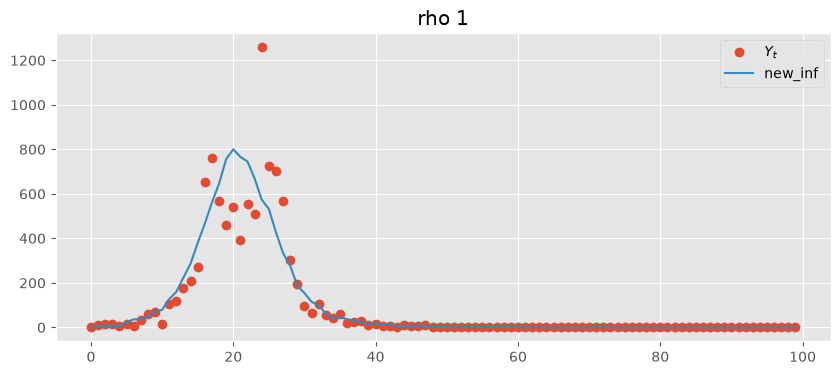

In [121]:
# Plot the observation model
plt.style.use('ggplot')
plt.figure(figsize=(10,4))
plt.plot(observed_data, label=r'$Y_t$', linestyle='', marker='o')
plt.plot(simulation_df['new_inf'], label='new_inf')
plt.title(f'{analysis} {reporting}')

plt.legend()

In [94]:
# Create DataFrame of observations (this is what Epydemix accepts)
observed_df = pd.DataFrame(observed_data)
observed_df = observed_df.rename(columns={0: 'data'})
observed_df['date'] = pd.date_range(start = '2024/01/01', periods = len(observed_df), freq='D')

In [95]:
# Priors
priors = {"beta": stats.gamma(4.5, scale = 0.1), 
          "gamma": stats.gamma(8, scale = .01)}

# Simulation parameters
parameters_noisy = {'N': 10000,
                    'n_i': 10,
                    'timesteps': 100,
                    'rho': .25,      # Reporting probability
                    'phi': 1}       # Overdispersion rate

# Wrapper function
def simulate_wrapper_noisy(parameters_noisy):
    results = stochastic_sir_noisy(**parameters_noisy)
    return{'data': results['noisy']}

# Initialize the ABCSampler object
abc_sampler_noisy = ABCSampler(simulation_function=simulate_wrapper_noisy,
                         priors = priors,
                         parameters=parameters_noisy,
                         observed_data=observed_df['data'],
                         distance_function = rmse)

Text(0.5, 0, 'gamma')

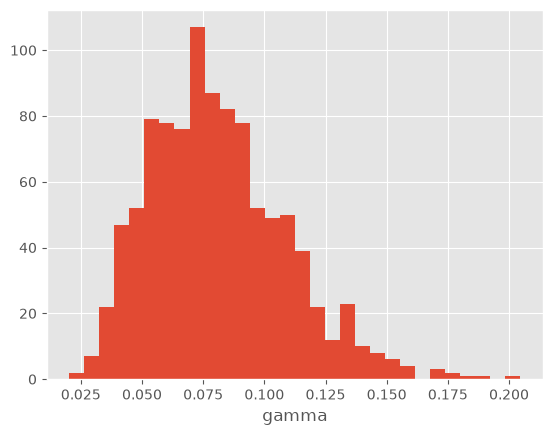

In [96]:
# Check priors are behaving correctly 
theta = priors['gamma'].rvs(size=1000)  # sample 1000 theta-parameters

plt.style.use('ggplot')
plt.hist(theta, 30);
plt.xlabel('gamma')


In [97]:
def smc_calibrate(seed):
    np.random.seed(seed)
    start = time.process_time()
    results_smc = abc_sampler_noisy.calibrate(strategy='smc',
                                    num_particles=1000,
                                    num_generations=9,
                                    )
    end = time.process_time()
    time_taken = end - start
    return results_smc, time_taken

In [115]:
start = time.process_time()
with mp.Pool() as pool:
    pool_smc = pool.map(smc_calibrate, [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])
end = time.process_time()

print(f"Time taken: {end - start:.2f} seconds")

Starting ABC-SMC with 1000 particles and 9 generationsStarting ABC-SMC with 1000 particles and 9 generationsStarting ABC-SMC with 1000 particles and 9 generationsStarting ABC-SMC with 1000 particles and 9 generationsStarting ABC-SMC with 1000 particles and 9 generationsStarting ABC-SMC with 1000 particles and 9 generationsStarting ABC-SMC with 1000 particles and 9 generationsStarting ABC-SMC with 1000 particles and 9 generationsStarting ABC-SMC with 1000 particles and 9 generationsStarting ABC-SMC with 1000 particles and 9 generations









Generation 1/9 (epsilon: inf)

Generation 1/9 (epsilon: inf)
Generation 1/9 (epsilon: inf)
Generation 1/9 (epsilon: inf)
Generation 1/9 (epsilon: inf)
Generation 1/9 (epsilon: inf)
Generation 1/9 (epsilon: inf)
Generation 1/9 (epsilon: inf)
Generation 1/9 (epsilon: inf)
Generation 1/9 (epsilon: inf)









	Accepted 1000/1000 (acceptance rate: 100.00%)	Accepted 1000/1000 (acceptance rate: 100.00%)

	Elapsed time: 00:00:00	Elapsed time: 00:00:00

In [118]:
print(pool_smc[4][1])

145.12756399999998


In [99]:
"""with open("abcsmc_5000_test.pkl", 'wb') as output:
    pickle.dump(pool_smc, output)"""

'with open("abcsmc_5000_test.pkl", \'wb\') as output:\n    pickle.dump(pool_smc, output)'

In [100]:
print(dir(pool_smc[0][0]))

['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_compute_quantiles', '_get_generation', 'calibration_params', 'calibration_strategy', 'distances', 'get_calibration_quantiles', 'get_calibration_trajectories', 'get_distances', 'get_posterior_distribution', 'get_projection_quantiles', 'get_projection_trajectories', 'get_selected_trajectories', 'get_weights', 'observed_data', 'posterior_distributions', 'priors', 'projection_parameters', 'projections', 'selected_trajectories', 'weights']


In [108]:
# Rho 1
beta_rho_1 = []
gamma_rho_1 = []
for i in range(8):
    beta_rho_1.append(np.array((pool_smc[i][0].get_posterior_distribution()['beta']).to_numpy()))
    gamma_rho_1.append(np.array((pool_smc[i][0].get_posterior_distribution()['gamma']).to_numpy()))

beta_rho_1 = np.array(beta_rho_1)
gamma_rho_1 = np.array(gamma_rho_1)

In [109]:
print(np.mean(gamma_rho_1))

0.1265336033733508


[-0.1, 0.5, 0.0, 35.0]

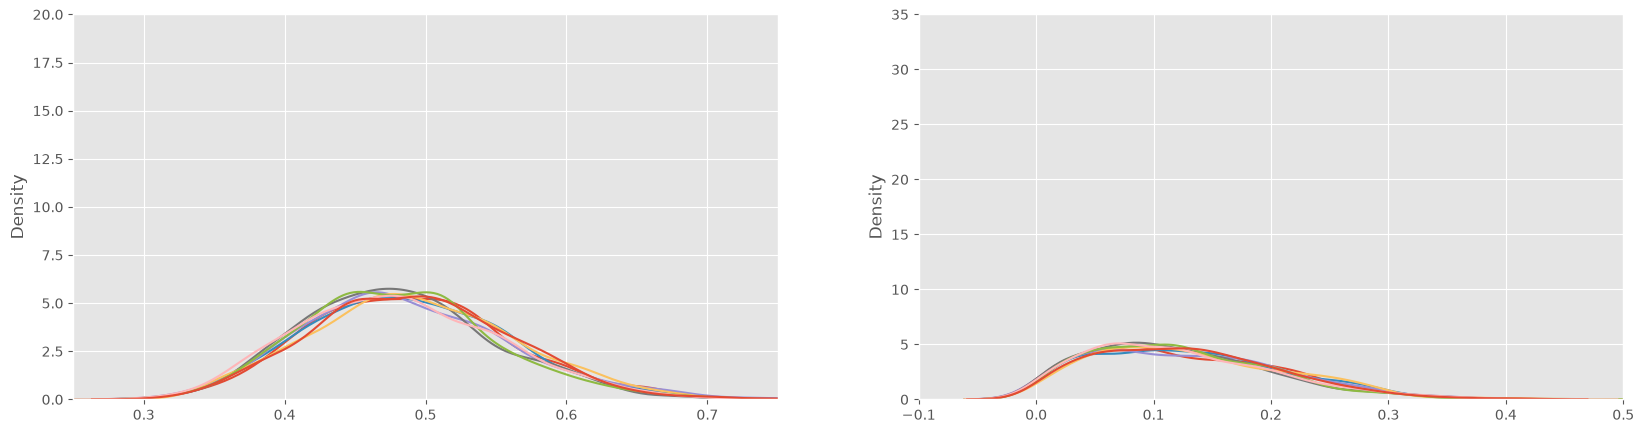

In [111]:
fig, axes = plt.subplots(1,2)


# BETA
for p in beta_rho_1:
    sb.kdeplot(p, ax=axes[0])
for p in gamma_rho_1:
    sb.kdeplot(p, ax=axes[1])


fig.set_figheight(5)
fig.set_figwidth(20)
plt.setp(axes[0], xlim=(0.25, 0.75), ylim=(0, 20))

plt.setp(axes[1], xlim=(-0.1, 0.5), ylim=(0, 35))

In [112]:
print(dir(pool_smc[3][0]))

['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_compute_quantiles', '_get_generation', 'calibration_params', 'calibration_strategy', 'distances', 'get_calibration_quantiles', 'get_calibration_trajectories', 'get_distances', 'get_posterior_distribution', 'get_projection_quantiles', 'get_projection_trajectories', 'get_selected_trajectories', 'get_weights', 'observed_data', 'posterior_distributions', 'priors', 'projection_parameters', 'projections', 'selected_trajectories', 'weights']


In [113]:
print(max((pool_smc[0][0]).distances[8]))

48.00739526364662


In [114]:
print((5000/1)+(5000/.31)+(5000/.15)+(5000/.08)+(5000/.05)+(5000/.03)+(5000/.02)+(5000/.01)+(5000/.005))

2133629.0322580645
